# Carga Repositorio del trabajo realizado en el artculo Identification of Surface Deformation in InSAR Using machine learning. Autores : Clayton M. J. Brengman y William D. Barnhart


In [ ]:
!git clone https://github.com/cbrengman/SarNet.git
!pip -q install numpy scipy pandas matplotlib opencv-python tqdm scikit-learn
!pip -q install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip install torchnet

Cloning into 'SarNet'...
remote: Enumerating objects: 583, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (11/11), done.
remote: Total 583 (delta 0), reused 0 (delta 0), pack-reused 572 (from 1)
Receiving objects: 100% (583/583), 238.70 MiB | 37.46 MiB/s, done.
Resolving deltas: 100% (19/19), done.
Updating files: 100% (564/564), done.


# Librerias

In [ ]:
import time
import os
import torch
import glob, random
import matplotlib.pyplot as plt
import glob, random
import numpy as np
import matplotlib.pyplot as plt



from torch import nn, optim
from torchvision import transforms
from torch.utils.data import DataLoader
from dataloaders.loaders import MyImageFolder
from models.CNN.DD.sarnet import sarnet1 as net
from PIL import Image
from tqdm import tqdm
from torch import nn, optim
from torchvision import transforms
from torch.utils.data import DataLoader
from dataloaders.loaders import MyImageFolder
from models.CNN.DD.sarnet import sarnet1 as net

# Main

In [ ]:
# Device

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device being used:", device)

def train_model(num_epochs=15, batch_size=20):

    model = net().to(device)

    loss_fn = nn.CrossEntropyLoss()

    optimizer = optim.SGD(model.parameters(), lr=0.01)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)


    # Dataset path

    directory = "/content/SarNet/Net/Transfer_Data/"

    print("\nChecking dataset structure...")
    print("Directory exists:", os.path.exists(directory))
    print("Train exists:", os.path.exists(os.path.join(directory, "train")))
    print("Val exists:", os.path.exists(os.path.join(directory, "val")))

    if not os.path.exists(os.path.join(directory, "train")):
        raise FileNotFoundError(f"Train folder not found: {os.path.join(directory,'train')}")
    if not os.path.exists(os.path.join(directory, "val")):
        raise FileNotFoundError(f"Val folder not found: {os.path.join(directory,'val')}")

    transform = transforms.Compose([
        transforms.Grayscale(),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])

    train_dataset = MyImageFolder(directory, mode="train", transform=transform)
    val_dataset = MyImageFolder(directory, mode="val", transform=transform)

    train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_dataloader = DataLoader(val_dataset, batch_size=batch_size * 2, shuffle=False)

    dataloaders = {"train": train_dataloader, "val": val_dataloader}
    dataset_sizes = {x: len(dataloaders[x].dataset) for x in ["train", "val"]}

    print("\nDataset sizes:", dataset_sizes)
    if dataset_sizes["train"] == 0 or dataset_sizes["val"] == 0:
        raise ValueError("Train or Val dataset is empty. Check folder structure and loader logic.")


# Dataloaders

    start = time.time()
    best_val_acc = 0.0
    best_path = None

    for epoch in tqdm(range(num_epochs), unit="epochs"):
        epoch_metrics = {}


        for phase in ["train", "val"]:
            running_loss = 0.0
            running_corrects = 0

            if phase == "train":
                model.train()
            else:
                model.eval()

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.float().to(device)
                labels = labels.to(device)

                optimizer.zero_grad(set_to_none=True)

                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = loss_fn(outputs, labels.long())

                    if phase == "train":
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data.long())

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = (running_corrects.double() / dataset_sizes[phase]).item()

            epoch_metrics[phase] = {"loss": epoch_loss, "acc": epoch_acc}
            print(f"{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")


        scheduler.step()


        val_acc = epoch_metrics["val"]["acc"]
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_path = f"SarNet_best_epoch_{epoch+1}.model"
            torch.save({
                "epoch": epoch + 1,
                "state_dict": model.state_dict(),
                "val_acc": best_val_acc,
                "opt_dict": optimizer.state_dict(),
            }, best_path)
            print(f"Saved new best checkpoint -> {best_path} (val_acc={best_val_acc:.4f})")

        time_elapsed = time.time() - start
        print(f"Epoch {epoch+1} completed in {time_elapsed/60:.2f} minutes\n")

    total = time.time() - start
    print(f"Training completed in {total/60:.2f} minutes")
    print(f"Best validation accuracy: {best_val_acc:.4f}")
    if best_path:
        print(f"Best checkpoint saved at: {best_path}")


if __name__ == "__main__":
    train_model(num_epochs=15, batch_size=20)

Device being used: cuda:0

Checking dataset structure...
Directory exists: True
Train exists: True
Val exists: True

Dataset sizes: {'train': 42, 'val': 12}


  0%|          | 0/15 [00:00<?, ?epochs/s]

train Loss: 0.7928 Acc: 0.4762
val Loss: 0.7750 Acc: 0.4167


  7%|▋         | 1/15 [00:00<00:10,  1.33epochs/s]

Saved new best checkpoint -> SarNet_best_epoch_1.model (val_acc=0.4167)
Epoch 1 completed in 0.01 minutes



...

train Loss: 0.9338 Acc: 0.5714
val Loss: 0.8038 Acc: 0.5833
Epoch 13 completed in 0.10 minutes



 93%|█████████▎| 14/15 [00:06<00:00,  2.30epochs/s]

train Loss: 0.8249 Acc: 0.5714
val Loss: 0.6995 Acc: 0.5833
Epoch 14 completed in 0.11 minutes



100%|██████████| 15/15 [00:06<00:00,  2.18epochs/s]

train Loss: 0.6101 Acc: 0.5714
val Loss: 0.6776 Acc: 0.5833
Epoch 15 completed in 0.11 minutes

Training completed in 0.11 minutes
Best validation accuracy: 0.5833
Best checkpoint saved at: SarNet_best_epoch_3.model


# Visualización de imágenes

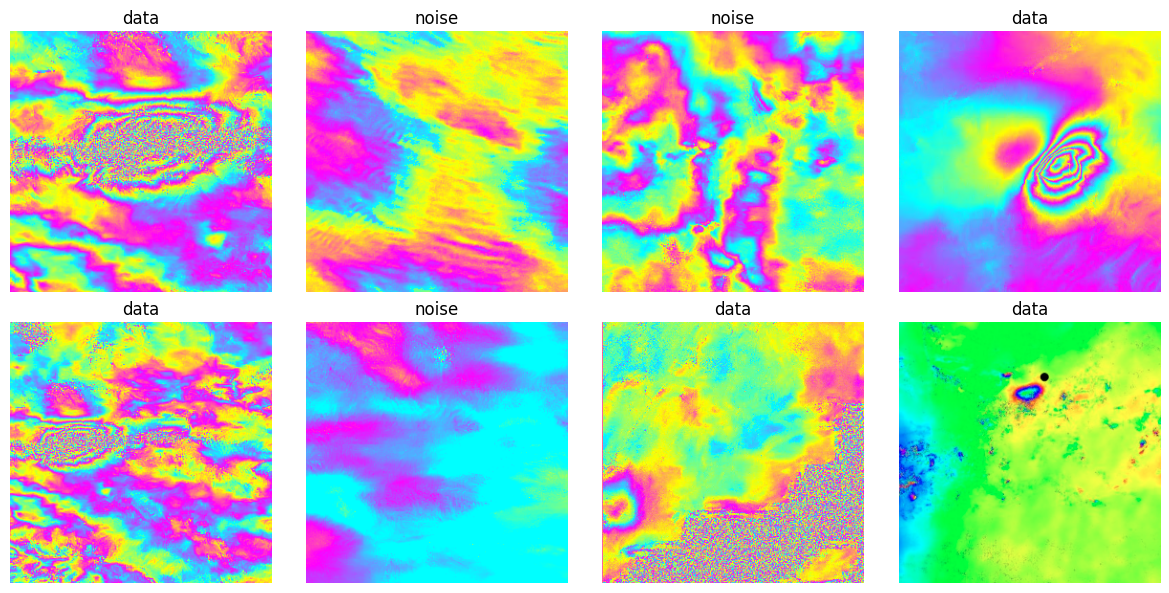

In [ ]:
paths = glob.glob("/content/SarNet/Net/Transfer_Data/train/data/*") + \
        glob.glob("/content/SarNet/Net/Transfer_Data/train/noise/*")

sample = random.sample(paths, k=min(8, len(paths)))

plt.figure(figsize=(12,6))
for i, p in enumerate(sample):
    img = Image.open(p)
    plt.subplot(2, 4, i+1)
    plt.imshow(img, cmap="gray")
    plt.title(p.split("/")[-2])
    plt.axis("off")
plt.tight_layout()
plt.show()

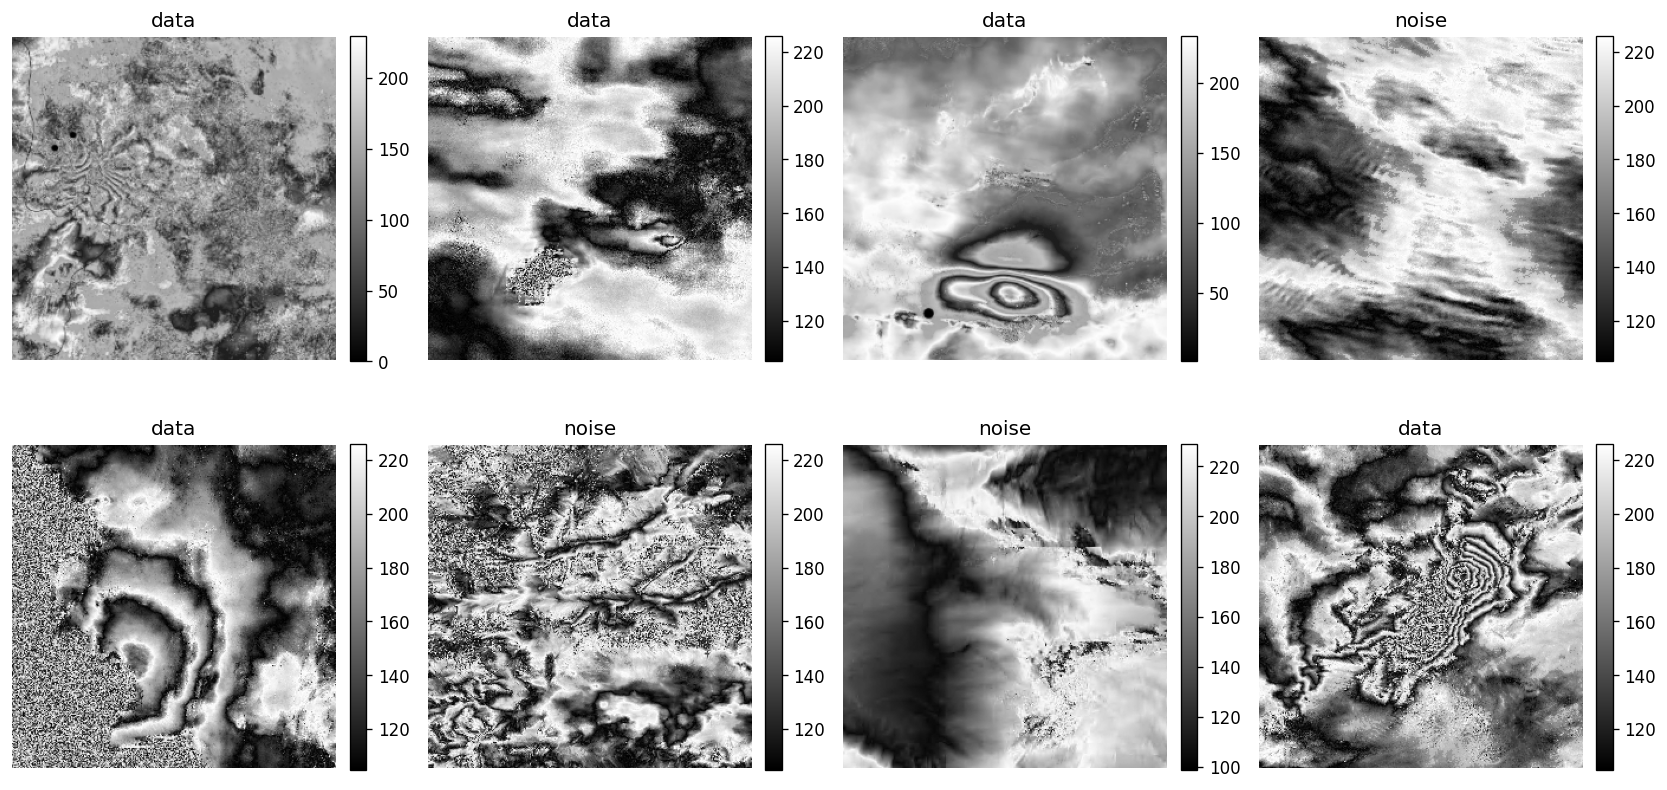

In [ ]:
paths = glob.glob("/content/SarNet/Net/Transfer_Data/train/data/*") + \
        glob.glob("/content/SarNet/Net/Transfer_Data/train/noise/*")

sample = random.sample(paths, k=min(8, len(paths)))

plt.figure(figsize=(14,7), dpi=120)

for i, p in enumerate(sample):
    img = Image.open(p).convert("L")
    img = np.array(img).astype(np.float32)

    ax = plt.subplot(2,4,i+1)
    im = ax.imshow(img, cmap="gray")
    ax.set_title(p.split("/")[-2])
    ax.axis("off")

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device being used:", device)


DATA_DIR = "/content/SarNet/Net/Transfer_Data/"
CKPT_PATH = "/content/SarNet/Net/SarNet_best_epoch_2.model"

assert os.path.exists(DATA_DIR), f"No existe DATA_DIR: {DATA_DIR}"
assert os.path.exists(CKPT_PATH), f"No existe CKPT_PATH: {CKPT_PATH}"


val_transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.CenterCrop(size=224),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])


# DataLoader

batch_size = 8
val_ds = MyImageFolder(DATA_DIR, mode="val", transform=val_transform)
val_dl = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

print("Val samples:", len(val_ds))

model = net().to(device)
criterion = nn.CrossEntropyLoss()

checkpoint = torch.load(CKPT_PATH, map_location=device)
model.load_state_dict(checkpoint["state_dict"])
model.eval()


running_loss = 0.0
running_corrects = 0
total = 0

with torch.no_grad():
    for x, y in val_dl:
        x = x.float().to(device)
        y = y.to(device)

        logits = model(x)
        loss = criterion(logits, y.long())

        preds = logits.argmax(dim=1)

        running_loss += loss.item() * x.size(0)
        running_corrects += (preds == y).sum().item()
        total += x.size(0)

avg_loss = running_loss / total
acc = running_corrects / total

print(f"VAL Loss: {avg_loss:.4f}  |  VAL Acc: {acc*100:.2f}%  ({running_corrects}/{total})")

Device being used: cuda:0
Val samples: 12
VAL Loss: 0.6944  |  VAL Acc: 58.33%  (7/12)
